In [1]:
import os
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
from transformers import SwinForImageClassification, SwinConfig, AutoImageProcessor
from tqdm import tqdm
import random
import matplotlib.pyplot as plt

# Set random seed and device
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

/home/yxu33/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [13]:
# Data transformations for fine-tuning Swin models on CIFAR-100
# IMPORTANT: We now resize to 224x224 so that the pretrained model's window configuration is preserved.
processor = AutoImageProcessor.from_pretrained("microsoft/swin-tiny-patch4-window7-224")
transform_ft = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize CIFAR-100 images (originally 32x32) to 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
])

# Load CIFAR-100 dataset for fine-tuning
train_dataset_ft = torchvision.datasets.CIFAR100(root='./datasets', train=True, download=True, transform=transform_ft)
test_dataset_ft = torchvision.datasets.CIFAR100(root='./datasets', train=False, download=True, transform=transform_ft)
# Split training dataset into train and validation sets (90% / 10%)
train_size_ft = int(0.9 * len(train_dataset_ft))
val_size_ft = len(train_dataset_ft) - train_size_ft
train_dataset_ft, val_dataset_ft = random_split(train_dataset_ft, [train_size_ft, val_size_ft])
train_loader_ft = DataLoader(train_dataset_ft, batch_size=32, shuffle=True, num_workers=2)
val_loader_ft = DataLoader(val_dataset_ft, batch_size=32, shuffle=False, num_workers=2)
test_loader_ft = DataLoader(test_dataset_ft, batch_size=32, shuffle=False, num_workers=2)

Files already downloaded and verified
Files already downloaded and verified


In [3]:
# Pretrained Swin-Tiny Fine-tuning
print("\nLoading pretrained Swin-Tiny model and fine-tuning...")
model_swin_tiny = SwinForImageClassification.from_pretrained(
    "microsoft/swin-tiny-patch4-window7-224",
    num_labels=100,  # CIFAR-100 has 100 classes
    ignore_mismatched_sizes=True
).to(device)
# Freeze backbone parameters so that only the classifier head is trained
for param in model_swin_tiny.swin.parameters():
    param.requires_grad = False
for param in model_swin_tiny.classifier.parameters():
    param.requires_grad = True

optimizer_tiny = optim.Adam(model_swin_tiny.classifier.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

def train_epoch_ft(model, dataloader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images).logits
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    return running_loss / len(dataloader.dataset)

def evaluate_ft(model, dataloader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images).logits
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)
    return running_loss / len(dataloader.dataset), correct / total

def train_model_ft(model, optimizer, num_epochs, criterion, train_loader, val_loader):
    train_losses = []
    val_losses = []
    val_accuracies = []
    epoch_times = []
    for epoch in range(num_epochs):
        start_time = time.time()
        tr_loss = train_epoch_ft(model, train_loader, optimizer, criterion)
        v_loss, v_acc = evaluate_ft(model, val_loader, criterion)
        elapsed = time.time() - start_time
        epoch_times.append(elapsed)
        train_losses.append(tr_loss)
        val_losses.append(v_loss)
        val_accuracies.append(v_acc)
        print(f"Epoch {epoch+1}/{num_epochs}: Train Loss: {tr_loss:.4f}, Val Loss: {v_loss:.4f}, Val Acc: {v_acc:.4f}, Time: {elapsed:.2f} s")
    return train_losses, val_losses, val_accuracies, epoch_times

num_epochs_ft = 5
print("Training Swin-Tiny (Pretrained)...")
tiny_train_losses, tiny_val_losses, tiny_val_accuracies, tiny_epoch_times = train_model_ft(
    model_swin_tiny, optimizer_tiny, num_epochs_ft, criterion, train_loader_ft, val_loader_ft
)

Some weights of SwinForImageClassification were not initialized from the model checkpoint at microsoft/swin-tiny-patch4-window7-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([100]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([100, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Loading pretrained Swin-Tiny model and fine-tuning...
Training Swin-Tiny (Pretrained)...
Epoch 1/5: Train Loss: 4.1188, Val Loss: 3.5964, Val Acc: 0.4520, Time: 84.79 s
Epoch 2/5: Train Loss: 3.1929, Val Loss: 2.7981, Val Acc: 0.5782, Time: 86.78 s
Epoch 3/5: Train Loss: 2.5254, Val Loss: 2.2459, Val Acc: 0.6254, Time: 87.52 s
Epoch 4/5: Train Loss: 2.0783, Val Loss: 1.8863, Val Acc: 0.6478, Time: 87.54 s
Epoch 5/5: Train Loss: 1.7813, Val Loss: 1.6494, Val Acc: 0.6614, Time: 87.72 s


In [4]:
# Pretrained Swin-Small Fine-tuning
print("\nLoading pretrained Swin-Small model and fine-tuning...")
model_swin_small = SwinForImageClassification.from_pretrained(
    "microsoft/swin-small-patch4-window7-224",
    num_labels=100,
    ignore_mismatched_sizes=True
).to(device)
# Freeze backbone and fine-tune only classifier head
for param in model_swin_small.swin.parameters():
    param.requires_grad = False
for param in model_swin_small.classifier.parameters():
    param.requires_grad = True

optimizer_small = optim.Adam(model_swin_small.classifier.parameters(), lr=2e-5)
print("Training Swin-Small (Pretrained)...")
small_train_losses, small_val_losses, small_val_accuracies, small_epoch_times = train_model_ft(
    model_swin_small, optimizer_small, num_epochs_ft, criterion, train_loader_ft, val_loader_ft
)


Loading pretrained Swin-Small model and fine-tuning...


Some weights of SwinForImageClassification were not initialized from the model checkpoint at microsoft/swin-small-patch4-window7-224 and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([100, 768]) in the model instantiated
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([100]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training Swin-Small (Pretrained)...
Epoch 1/5: Train Loss: 4.0230, Val Loss: 3.4529, Val Acc: 0.5166, Time: 142.86 s
Epoch 2/5: Train Loss: 3.0074, Val Loss: 2.5996, Val Acc: 0.6180, Time: 143.97 s
Epoch 3/5: Train Loss: 2.3001, Val Loss: 2.0365, Val Acc: 0.6570, Time: 143.97 s
Epoch 4/5: Train Loss: 1.8493, Val Loss: 1.6885, Val Acc: 0.6842, Time: 143.82 s
Epoch 5/5: Train Loss: 1.5676, Val Loss: 1.4696, Val Acc: 0.6938, Time: 143.91 s


In [6]:
# Swin Transformer from Scratch
print("\nInitializing Swin Transformer from scratch...")
# Create a config from a pretrained Swin-Tiny config and modify for CIFAR-100
config = SwinConfig.from_pretrained("microsoft/swin-tiny-patch4-window7-224")
config.num_labels = 100
# Instantiate model from config (randomly initialized)
model_swin_scratch = SwinForImageClassification(config).to(device)

optimizer_scratch = optim.Adam(model_swin_scratch.parameters(), lr=0.001)

print("Training Swin Transformer from scratch...")
scratch_train_losses, scratch_val_losses, scratch_val_accuracies, scratch_epoch_times = train_model_ft(
    model_swin_scratch, optimizer_scratch, num_epochs_ft, criterion, train_loader_ft, val_loader_ft
)


Initializing Swin Transformer from scratch...
Training Swin Transformer from scratch...
Epoch 1/5: Train Loss: 4.6784, Val Loss: 4.6190, Val Acc: 0.0066, Time: 212.14 s
Epoch 2/5: Train Loss: 4.6262, Val Loss: 4.6147, Val Acc: 0.0106, Time: 215.06 s
Epoch 3/5: Train Loss: 4.6148, Val Loss: 4.6102, Val Acc: 0.0076, Time: 215.15 s
Epoch 4/5: Train Loss: 4.6117, Val Loss: 4.6134, Val Acc: 0.0094, Time: 215.42 s
Epoch 5/5: Train Loss: 4.6100, Val Loss: 4.6115, Val Acc: 0.0090, Time: 215.64 s


In [7]:
# Gather training curves for plotting (for all three models)
# We'll store curves in a list of dictionaries
ft_curve_results = [
    {"name": "Pretrained Swin-Tiny", "train_losses": tiny_train_losses, "val_losses": tiny_val_losses, "val_accuracies": tiny_val_accuracies},
    {"name": "Pretrained Swin-Small", "train_losses": small_train_losses, "val_losses": small_val_losses, "val_accuracies": small_val_accuracies},
    {"name": "Swin from Scratch", "train_losses": scratch_train_losses, "val_losses": scratch_val_losses, "val_accuracies": scratch_val_accuracies}
]

In [9]:
# Summary Table: compute parameter counts and average epoch times
def avg_time(epoch_times):
    return sum(epoch_times) / len(epoch_times)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

tiny_params = count_parameters(model_swin_tiny)
small_params = count_parameters(model_swin_small)
scratch_params = count_parameters(model_swin_scratch)

print("\n--- Summary for Fine-tuned Swin Models ---")
print(f"Pretrained Swin-Tiny: Params: {tiny_params}, Avg Epoch Time: {avg_time(tiny_epoch_times):.2f} s, Final Val Acc: {tiny_val_accuracies[-1]*100:.2f}%")
print(f"Pretrained Swin-Small: Params: {small_params}, Avg Epoch Time: {avg_time(small_epoch_times):.2f} s, Final Val Acc: {small_val_accuracies[-1]*100:.2f}%")
print(f"Swin from Scratch: Params: {scratch_params}, Avg Epoch Time: {avg_time(scratch_epoch_times):.2f} s, Final Val Acc: {scratch_val_accuracies[-1]*100:.2f}%")


--- Summary for Fine-tuned Swin Models ---
Pretrained Swin-Tiny: Params: 76900, Avg Epoch Time: 86.87 s, Final Val Acc: 66.14%
Pretrained Swin-Small: Params: 76900, Avg Epoch Time: 143.70 s, Final Val Acc: 69.38%
Swin from Scratch: Params: 27596254, Avg Epoch Time: 214.68 s, Final Val Acc: 0.90%


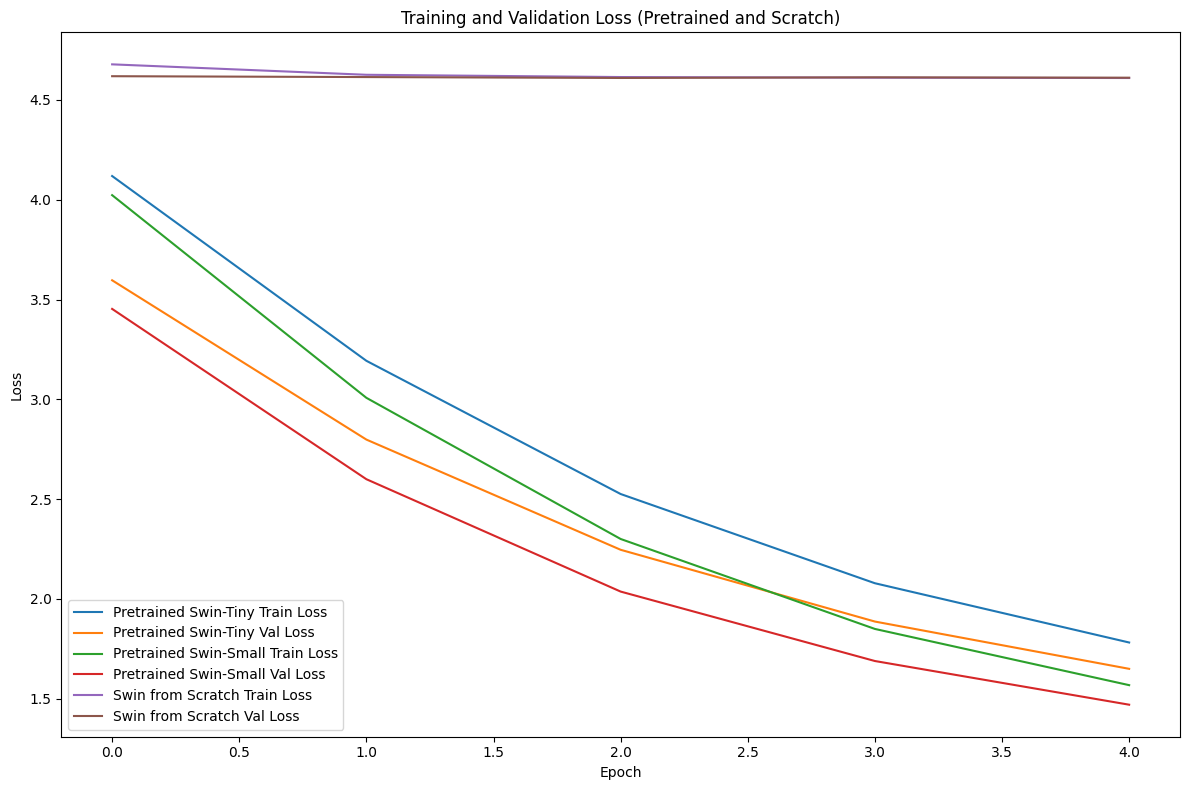

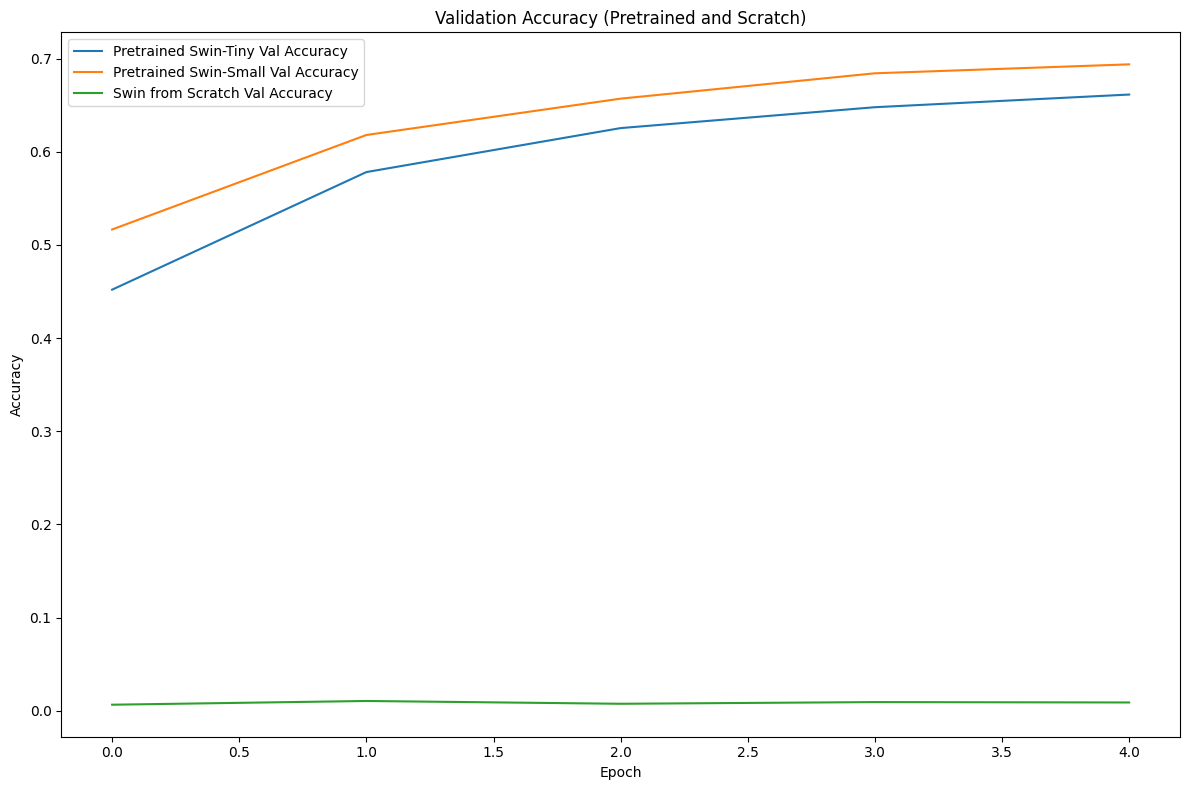

In [10]:
# Plot training & validation curves for all three models
plt.figure(figsize=(12, 8))
for data in ft_curve_results:
    plt.plot(data["train_losses"], label=f'{data["name"]} Train Loss')
    plt.plot(data["val_losses"], label=f'{data["name"]} Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss (Pretrained and Scratch)")
plt.legend()
plt.tight_layout()
plt.savefig("./images/p2_swin_loss_comparison.png")
plt.show()

plt.figure(figsize=(12, 8))
for data in ft_curve_results:
    plt.plot(data["val_accuracies"], label=f'{data["name"]} Val Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy (Pretrained and Scratch)")
plt.legend()
plt.tight_layout()
plt.savefig("./images/p2_swin_accuracy_comparison.png")
plt.show()

In [11]:
# Define testing function to compute predictions
def compute_metrics_ft(model, dataloader):
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images).logits
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())
    return np.array(all_preds), np.array(all_targets)

In [12]:
# Evaluate all three models on test set and store results in a dictionary
test_models = {
    "Pretrained Swin-Tiny": model_swin_tiny,
    "Pretrained Swin-Small": model_swin_small,
    "Swin from Scratch": model_swin_scratch
}

print("Test Set Evaluation")
for model_name, model_instance in test_models.items():
    preds, targets = compute_metrics_ft(model_instance, test_loader_ft)
    test_acc = np.mean(preds == targets)
    print(f"{model_name} Test Accuracy: {test_acc*100:.2f}%")

Test Set Evaluation
Pretrained Swin-Tiny Test Accuracy: 65.60%
Pretrained Swin-Small Test Accuracy: 69.48%
Swin from Scratch Test Accuracy: 1.00%
